# 02 · Feature Engineering

Turn the raw tables into a clean, all-numeric feature matrix: clean the application table and add credit ratios, aggregate each satellite table to one row per applicant, encode categoricals, split train/validation, and frequency-encode high-cardinality columns (fit on train only).

In [1]:
import sys
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.append("..")
from src import data_prep, features

RAW = "../data/raw"
FIG_DIR = "../reports/figures"
pd.set_option("display.max_columns", 40)

## 1 · Application table: clean + credit ratios

In [2]:
app = data_prep.load_application(f"{RAW}/application_train.csv")
app = data_prep.clean_application(app)
app = features.add_credit_ratios(app)

print("Application table with ratios:", app.shape)
app[["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_GOODS_RATIO",
     "ANNUITY_CREDIT_RATIO", "EMPLOYED_AGE_RATIO"]].describe().round(2)

Application table with ratios: (307511, 129)


,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,ANNUITY_CREDIT_RATIO,EMPLOYED_AGE_RATIO
count,307511.00,307499.00,307233.00,307499.00,252137.00
mean,3.96,0.18,1.12,0.05,0.16
std,2.69,0.09,0.12,0.02,0.13
min,0.00,0.00,0.15,0.02,-0.00
25%,2.02,0.11,1.00,0.04,0.06
50%,3.27,0.16,1.12,0.05,0.12
75%,5.16,0.23,1.20,0.06,0.22
max,84.74,1.88,6.00,0.12,0.73


Check that a ratio carries signal: does the default rate rise with the credit-to-income ratio?

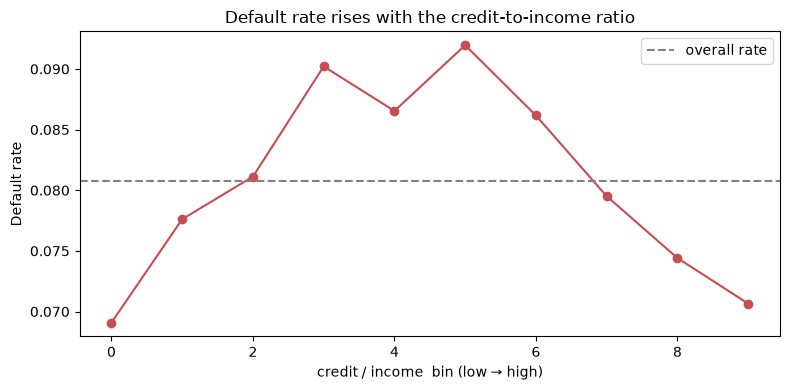

In [3]:
tmp = app.dropna(subset=["CREDIT_INCOME_RATIO"]).copy()
tmp["bin"] = pd.qcut(tmp["CREDIT_INCOME_RATIO"], q=10, duplicates="drop")
rate_by_ratio = tmp.groupby("bin", observed=True)["TARGET"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(rate_by_ratio)), rate_by_ratio.values, marker="o", color="#c44e52")
ax.axhline(app["TARGET"].mean(), color="grey", linestyle="--", label="overall rate")
ax.set_title("Default rate rises with the credit-to-income ratio")
ax.set_xlabel("credit / income  bin (low → high)")
ax.set_ylabel("Default rate")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_credit_income_ratio.png", dpi=120)
plt.show()

## 2 · Aggregate the satellite tables

Each satellite table has many rows per applicant; summarize to one row per `SK_ID_CURR` and join. Columns are prefixed by source (`BURO_`, `PREV_`, `INST_`, `POS_`, `CC_`).

In [4]:
block_sizes = {"application (with ratios)": app.shape[1]}

buro = features.aggregate_bureau(f"{RAW}/bureau.csv", f"{RAW}/bureau_balance.csv")
app = app.merge(buro, on="SK_ID_CURR", how="left")
block_sizes["+ bureau"] = app.shape[1]

prev = features.aggregate_previous(f"{RAW}/previous_application.csv")
app = app.merge(prev, on="SK_ID_CURR", how="left")
block_sizes["+ previous"] = app.shape[1]

inst = features.aggregate_installments(f"{RAW}/installments_payments.csv")
app = app.merge(inst, on="SK_ID_CURR", how="left")
block_sizes["+ installments"] = app.shape[1]

pos = features.aggregate_pos(f"{RAW}/POS_CASH_balance.csv")
app = app.merge(pos, on="SK_ID_CURR", how="left")
block_sizes["+ pos"] = app.shape[1]

cc = features.aggregate_credit_card(f"{RAW}/credit_card_balance.csv")
app = app.merge(cc, on="SK_ID_CURR", how="left")
block_sizes["+ credit_card"] = app.shape[1]

print("Columns after each block:")
for name, n in block_sizes.items():
    print(f"  {name:28s} {n}")

Columns after each block:
  application (with ratios)    129
  + bureau                     140
  + previous                   147
  + installments               152
  + pos                        157
  + credit_card                161


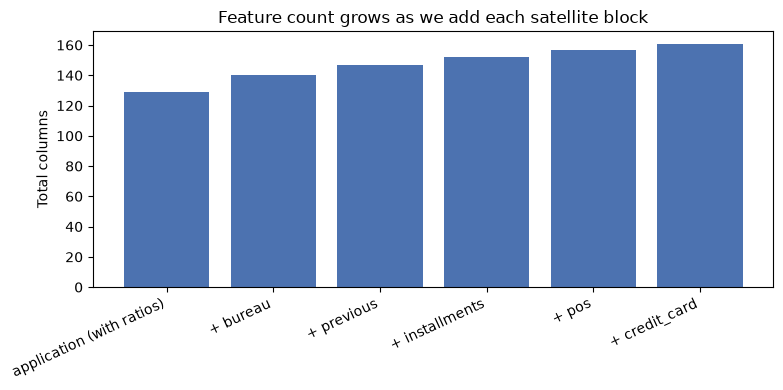

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(block_sizes.keys()), list(block_sizes.values()), color="#4c72b0")
ax.set_ylabel("Total columns")
ax.set_title("Feature count grows as we add each satellite block")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_feature_growth.png", dpi=120)
plt.show()

## 3 · Tidy up

Replace infinities with `NaN`, set gender aside for the fairness audit (never a model feature), and drop the raw negative-day columns.

In [6]:
app = app.replace([np.inf, -np.inf], np.nan)

sensitive = app[["SK_ID_CURR", "CODE_GENDER"]].copy()
app = app.drop(columns=["CODE_GENDER", "DAYS_BIRTH", "DAYS_EMPLOYED"])
print("Shape after tidy-up:", app.shape)

Shape after tidy-up: (307511, 158)


## 4 · Encode categorical columns

One-hot the low-cardinality columns now; frequency-encode the high-cardinality ones after the split (train only).

In [7]:
object_cols = list(app.select_dtypes("object").columns)
cardinality = {c: app[c].nunique() for c in object_cols}
high_card = [c for c, n in cardinality.items() if n > 15]
low_card = [c for c in object_cols if c not in high_card]

print("high-cardinality (frequency-encode later):", high_card)
print(f"low-cardinality (one-hot now): {len(low_card)} columns")

app = pd.get_dummies(app, columns=low_card, dummy_na=False, dtype=int)
print("Shape after one-hot:", app.shape)

C:\Users\shada\AppData\Local\Temp\ipykernel_18304\802049792.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = list(app.select_dtypes("object").columns)


high-cardinality (frequency-encode later): ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
low-cardinality (one-hot now): 13 columns


Shape after one-hot: (307511, 206)


## 5 · Train / validation split (stratified)

A random 80/20 split that keeps the 8% default rate in both parts.

In [8]:
train, valid = train_test_split(
    app, test_size=0.2, stratify=app["TARGET"], random_state=42,
)
print("train:", train.shape, " valid:", valid.shape)
print("default rate  train: {:.4f}   valid: {:.4f}".format(
    train["TARGET"].mean(), valid["TARGET"].mean()))

train: (246008, 206)  valid: (61503, 206)
default rate  train: 0.0807   valid: 0.0807


## 6 · Frequency-encode high-cardinality columns — fit on train only

Leakage guard: frequencies are learned from training rows, then applied to both.

In [9]:
for col in high_card:
    freq = train[col].value_counts(normalize=True)     # train only
    train[col + "_FREQ"] = train[col].map(freq)
    valid[col + "_FREQ"] = valid[col].map(freq).fillna(0)

train = train.drop(columns=high_card)
valid = valid.drop(columns=high_card)
print("train:", train.shape, " valid:", valid.shape)

train: (246008, 206)  valid: (61503, 206)


## 7 · Clean column names and save

In [10]:
def clean_name(name):
    return re.sub(r"[^0-9a-zA-Z_]+", "_", name).strip("_")

train.columns = [clean_name(c) for c in train.columns]
valid.columns = [clean_name(c) for c in valid.columns]

train = train.set_index("SK_ID_CURR")
valid = valid.set_index("SK_ID_CURR")

assert train.select_dtypes("object").shape[1] == 0, "still have text columns!"
assert list(train.columns) == list(valid.columns), "train/valid columns differ!"
print("All-numeric:", train.select_dtypes('object').shape[1] == 0)
print("Final train:", train.shape, " valid:", valid.shape)

train.to_parquet("../data/processed/train.parquet")
valid.to_parquet("../data/processed/valid.parquet")
sensitive.set_index("SK_ID_CURR").to_parquet("../data/processed/sensitive.parquet")

All-numeric: True
Final train: (246008, 205)  valid: (61503, 205)


In [11]:
# record which block each feature came from
prefixes = {"BURO_": "bureau", "PREV_": "previous", "INST_": "installments",
            "POS_": "pos", "CC_": "credit_card"}
blocks = {name: [] for name in prefixes.values()}
blocks["application"] = []
for col in train.columns:
    if col == "TARGET":
        continue
    for pre, name in prefixes.items():
        if col.startswith(pre):
            blocks[name].append(col)
            break
    else:
        blocks["application"].append(col)

with open("../data/processed/feature_blocks.json", "w") as f:
    json.dump(blocks, f, indent=2)

print("Features per block:")
for name, cols in blocks.items():
    print(f"  {name:14s} {len(cols)}")

Features per block:
  bureau         11
  previous       7
  installments   5
  pos            5
  credit_card    4
  application    172


## Takeaways

- 122 raw columns → **204 features**.
- Ratios and satellite aggregations add the real signal; each block is measured later.
- Leakage guards: gender excluded from features; frequency encoding fit on train only.
- Saved `train.parquet`, `valid.parquet`, `sensitive.parquet`, `feature_blocks.json`.